# Marketing Campaign Performance Analysis Using Python

## Project 3: Python Exploratory Data Analysis

This notebook analyzes a marketing campaign performance dataset using Python. The goal is to clean the data, explore campaign performance, identify high-performing channels and segments, and produce business recommendations for marketing budget optimization.

## Business Problem

The marketing team wants to understand which campaigns, channels, customer segments, and target audiences deliver the strongest campaign performance. The analysis focuses on ROI, conversion rate, clicks, impressions, engagement, acquisition cost, and cost efficiency.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Use a clean default chart size
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load Dataset

Place the raw Kaggle CSV file in:

`../data/raw/marketing_campaign_dataset.csv`

In [3]:
RAW_DATA_PATH = Path("../data/raw/marketing_campaign_dataset.csv")

df = pd.read_csv(RAW_DATA_PATH)
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


## 3. Initial Dataset Inspection

In [4]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Rows and columns: (200000, 16)

Column names:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

Data types:


Campaign_ID           int64
Company                 str
Campaign_Type           str
Target_Audience         str
Duration                str
Channel_Used            str
Conversion_Rate     float64
Acquisition_Cost        str
ROI                 float64
Location                str
Language                str
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment        str
Date                    str
dtype: object


Missing values:


Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


Duplicate rows: 0


## 4. Data Cleaning

Cleaning actions:
- Standardize column names
- Convert date column to datetime
- Convert acquisition cost from currency text to numeric
- Extract numeric campaign duration
- Create time-based columns
- Create campaign performance metrics

In [5]:
cleaned_df = df.copy()

# Standardize column names
cleaned_df.columns = (
    cleaned_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Convert date
cleaned_df["date"] = pd.to_datetime(cleaned_df["date"], errors="coerce")

# Convert acquisition cost from "$16,174.00" to numeric
cleaned_df["acquisition_cost"] = (
    cleaned_df["acquisition_cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Extract numeric duration
cleaned_df["duration_days"] = cleaned_df["duration"].str.extract(r"(\d+)").astype(int)

# Time features
cleaned_df["year"] = cleaned_df["date"].dt.year
cleaned_df["month_no"] = cleaned_df["date"].dt.month
cleaned_df["month_name"] = cleaned_df["date"].dt.strftime("%b")
cleaned_df["year_month"] = cleaned_df["date"].dt.to_period("M").astype(str)

# Performance metrics
cleaned_df["ctr"] = cleaned_df["clicks"] / cleaned_df["impressions"]
cleaned_df["estimated_conversions"] = cleaned_df["clicks"] * cleaned_df["conversion_rate"]
cleaned_df["cost_per_click"] = cleaned_df["acquisition_cost"] / cleaned_df["clicks"].replace(0, np.nan)
cleaned_df["cost_per_conversion"] = cleaned_df["acquisition_cost"] / cleaned_df["estimated_conversions"].replace(0, np.nan)

# ROI-derived estimates
# Note: Treating ROI as a multiplier/score from the dataset for analytical comparison.
cleaned_df["estimated_revenue_from_roi"] = cleaned_df["acquisition_cost"] * cleaned_df["roi"]
cleaned_df["estimated_profit_from_roi"] = cleaned_df["estimated_revenue_from_roi"] - cleaned_df["acquisition_cost"]

# Bands
cleaned_df["roi_band"] = pd.cut(
    cleaned_df["roi"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["Low ROI (<2)", "Medium ROI (2-4)", "High ROI (4+)"]
)

cleaned_df["engagement_band"] = pd.cut(
    cleaned_df["engagement_score"],
    bins=[0, 3, 7, 10],
    labels=["Low Engagement", "Medium Engagement", "High Engagement"],
    include_lowest=True
)

cleaned_df.head()

,campaign_id,company,campaign_type,target_audience,duration,channel_used,conversion_rate,acquisition_cost,roi,location,language,clicks,impressions,engagement_score,customer_segment,date,duration_days,year,month_no,month_name,year_month,ctr,estimated_conversions,cost_per_click,cost_per_conversion,estimated_revenue_from_roi,estimated_profit_from_roi,roi_band,engagement_band
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,30,2021,1,Jan,2021-01,0.26,20.24,31.96,799.11,"101,734.46","85,560.46",High ROI (4+),Medium Engagement
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,60,2021,1,Jan,2021-01,0.02,13.92,99.71,830.89,"64,885.26","53,319.26",High ROI (4+),Medium Engagement
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,30,2021,1,Jan,2021-01,0.08,40.88,17.47,249.51,"73,236.00","63,036.00",High ROI (4+),Low Engagement
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,60,2021,1,Jan,2021-01,0.12,23.87,58.64,533.05,"70,618.20","57,894.20",High ROI (4+),Medium Engagement
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,15,2021,1,Jan,2021-01,0.09,18.95,43.41,868.18,"106,938.00","90,486.00",High ROI (4+),Low Engagement


## 5. Data Quality Validation After Cleaning

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Missing values",
        "Duplicate rows",
        "Invalid dates",
        "Date start",
        "Date end"
    ],
    "value": [
        cleaned_df.shape[0],
        cleaned_df.shape[1],
        cleaned_df.isna().sum().sum(),
        cleaned_df.duplicated().sum(),
        cleaned_df["date"].isna().sum(),
        cleaned_df["date"].min(),
        cleaned_df["date"].max()
    ]
})

quality_summary

,metric,value
0,Rows,200000
1,Columns,29
2,Missing values,0
3,Duplicate rows,0
4,Invalid dates,0
5,Date start,2021-01-01 00:00:00
6,Date end,2021-12-31 00:00:00


## 6. Save Cleaned Dataset

In [11]:
CLEANED_DATA_PATH = Path("../data/cleaned/marketing_campaign_cleaned.csv")
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

cleaned_df.to_csv(CLEANED_DATA_PATH, index=False)
print(f"Cleaned dataset saved to: {CLEANED_DATA_PATH}")

Cleaned dataset saved to: ..\data\cleaned\marketing_campaign_cleaned.csv


## 7. KPI Summary

In [12]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Campaigns",
        "Total Acquisition Cost",
        "Average Acquisition Cost",
        "Average ROI",
        "Average Conversion Rate",
        "Total Clicks",
        "Total Impressions",
        "Overall CTR",
        "Average Engagement Score",
        "Estimated Conversions",
        "Average CPC",
        "Average Cost per Conversion"
    ],
    "Value": [
        cleaned_df["campaign_id"].nunique(),
        cleaned_df["acquisition_cost"].sum(),
        cleaned_df["acquisition_cost"].mean(),
        cleaned_df["roi"].mean(),
        cleaned_df["conversion_rate"].mean(),
        cleaned_df["clicks"].sum(),
        cleaned_df["impressions"].sum(),
        cleaned_df["clicks"].sum() / cleaned_df["impressions"].sum(),
        cleaned_df["engagement_score"].mean(),
        cleaned_df["estimated_conversions"].sum(),
        cleaned_df["acquisition_cost"].sum() / cleaned_df["clicks"].sum(),
        cleaned_df["acquisition_cost"].sum() / cleaned_df["estimated_conversions"].sum()
    ]
})

kpi_summary

,KPI,Value
0,Total Campaigns,"200,000.00"
1,Total Acquisition Cost,"2,500,878,608.00"
2,Average Acquisition Cost,"12,504.39"
3,Average ROI,5.00
4,Average Conversion Rate,0.08
5,Total Clicks,"109,954,406.00"
6,Total Impressions,"1,101,460,304.00"
7,Overall CTR,0.10
8,Average Engagement Score,5.49
9,Estimated Conversions,"8,804,579.69"


## 8. Reusable Summary Function

In [13]:
def performance_summary(group_col):
    summary = (
        cleaned_df.groupby(group_col)
        .agg(
            campaigns=("campaign_id", "count"),
            total_cost=("acquisition_cost", "sum"),
            avg_roi=("roi", "mean"),
            avg_conversion_rate=("conversion_rate", "mean"),
            clicks=("clicks", "sum"),
            impressions=("impressions", "sum"),
            avg_engagement=("engagement_score", "mean"),
            estimated_conversions=("estimated_conversions", "sum")
        )
        .reset_index()
    )

    summary["ctr"] = summary["clicks"] / summary["impressions"]
    summary["cost_per_click"] = summary["total_cost"] / summary["clicks"]
    summary["cost_per_conversion"] = summary["total_cost"] / summary["estimated_conversions"]

    return summary.sort_values("avg_roi", ascending=False)

channel_summary = performance_summary("channel_used")
channel_summary

,channel_used,campaigns,total_cost,avg_roi,avg_conversion_rate,clicks,impressions,avg_engagement,estimated_conversions,ctr,cost_per_click,cost_per_conversion
1,Facebook,32819,"410,595,258.00",5.02,0.08,18037947,180659428,5.50,"1,446,290.30",0.10,22.76,283.90
4,Website,33360,"416,593,500.00",5.01,0.08,18414628,183806353,5.51,"1,477,710.16",0.10,22.62,281.92
2,Google Ads,33438,"418,912,314.00",5.00,0.08,18340807,185006879,5.49,"1,468,753.09",0.10,22.84,285.22
0,Email,33599,"420,874,104.00",5.00,0.08,18493963,184801107,5.49,"1,485,393.65",0.10,22.76,283.34
5,YouTube,33392,"416,778,582.00",4.99,0.08,18350407,183448082,5.48,"1,463,568.01",0.10,22.71,284.77
3,Instagram,33392,"417,124,850.00",4.99,0.08,18316654,183738455,5.49,"1,462,864.48",0.10,22.77,285.14


## 9. Channel Performance Analysis

,channel_used,campaigns,total_cost,avg_roi,avg_conversion_rate,clicks,impressions,avg_engagement,estimated_conversions,ctr,cost_per_click,cost_per_conversion
1,Facebook,32819,"410,595,258.00",5.02,0.08,18037947,180659428,5.50,"1,446,290.30",0.10,22.76,283.90
4,Website,33360,"416,593,500.00",5.01,0.08,18414628,183806353,5.51,"1,477,710.16",0.10,22.62,281.92
2,Google Ads,33438,"418,912,314.00",5.00,0.08,18340807,185006879,5.49,"1,468,753.09",0.10,22.84,285.22
0,Email,33599,"420,874,104.00",5.00,0.08,18493963,184801107,5.49,"1,485,393.65",0.10,22.76,283.34
5,YouTube,33392,"416,778,582.00",4.99,0.08,18350407,183448082,5.48,"1,463,568.01",0.10,22.71,284.77
3,Instagram,33392,"417,124,850.00",4.99,0.08,18316654,183738455,5.49,"1,462,864.48",0.10,22.77,285.14


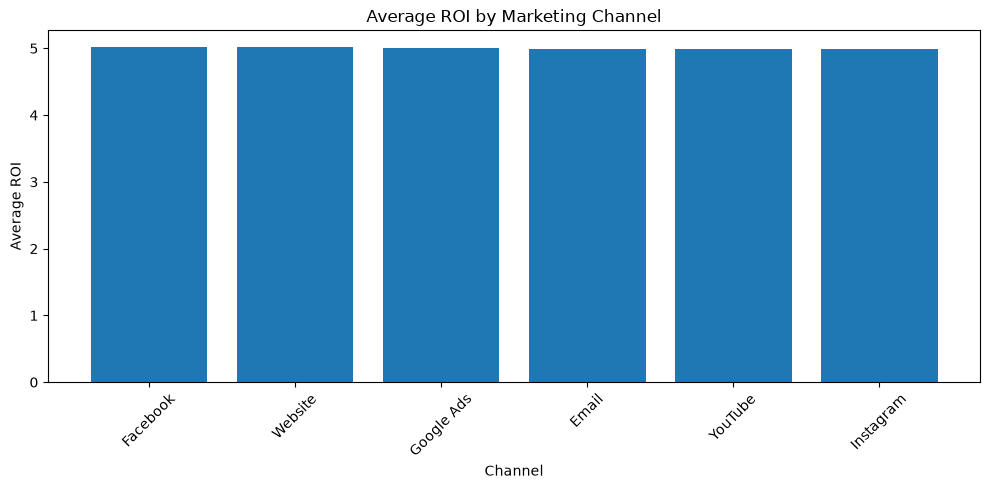

In [22]:
channel_summary = performance_summary("channel_used")
display(channel_summary)

plt.figure()
plt.bar(channel_summary["channel_used"], channel_summary["avg_roi"])
plt.title("Average ROI by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/avg_roi_by_channel.png", dpi=150)
plt.show()

## 10. Campaign Type Performance

,campaign_type,campaigns,total_cost,avg_roi,avg_conversion_rate,clicks,impressions,avg_engagement,estimated_conversions,ctr,cost_per_click,cost_per_conversion
2,Influencer,40169,"502,400,525.00",5.01,0.08,22037657,220769081,5.48,"1,771,218.18",0.10,22.80,283.65
3,Search,40157,"501,911,760.00",5.01,0.08,22032144,221415139,5.49,"1,764,203.50",0.10,22.78,284.50
0,Display,39987,"500,158,774.00",5.01,0.08,22030979,220074756,5.51,"1,763,752.74",0.10,22.70,283.58
1,Email,39870,"498,189,449.00",4.99,0.08,21897902,220144927,5.50,"1,746,961.36",0.10,22.75,285.17
4,Social Media,39817,"498,218,100.00",4.99,0.08,21955724,219056401,5.50,"1,758,443.91",0.10,22.69,283.33


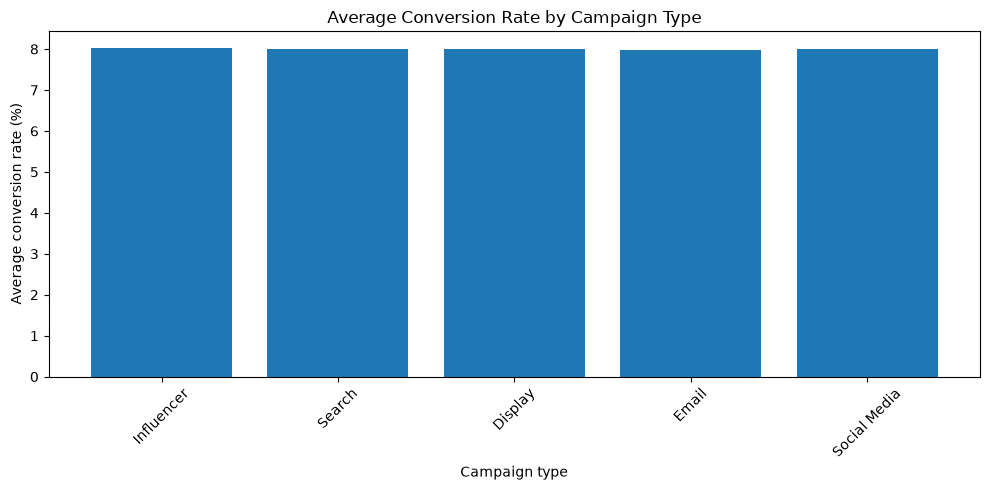

In [29]:
campaign_type_summary = performance_summary("campaign_type")
display(campaign_type_summary)

plt.figure()
plt.bar(campaign_type_summary["campaign_type"], campaign_type_summary["avg_conversion_rate"] * 100)
plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Campaign type")
plt.ylabel("Average conversion rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/conversion_rate_by_campaign_type.png", dpi=150)
plt.show()

## 11. Customer Segment Performance

,customer_segment,campaigns,total_cost,avg_roi,avg_conversion_rate,clicks,impressions,avg_engagement,estimated_conversions,ctr,cost_per_click,cost_per_conversion
1,Foodies,40208,"503,587,434.00",5.00,0.08,22080774,220815116,5.51,"1,774,104.19",0.10,22.81,283.85
4,Tech Enthusiasts,40151,"501,100,259.00",5.00,0.08,22035992,220385244,5.49,"1,764,788.77",0.10,22.74,283.94
2,Health & Wellness,39888,"498,776,239.00",5.00,0.08,21953923,220457458,5.48,"1,754,118.10",0.10,22.72,284.35
0,Fashionistas,39742,"496,911,934.00",5.00,0.08,21855164,219253627,5.49,"1,744,293.84",0.10,22.74,284.88
3,Outdoor Adventurers,40011,"500,502,742.00",5.00,0.08,22028553,220548859,5.50,"1,767,274.79",0.10,22.72,283.21


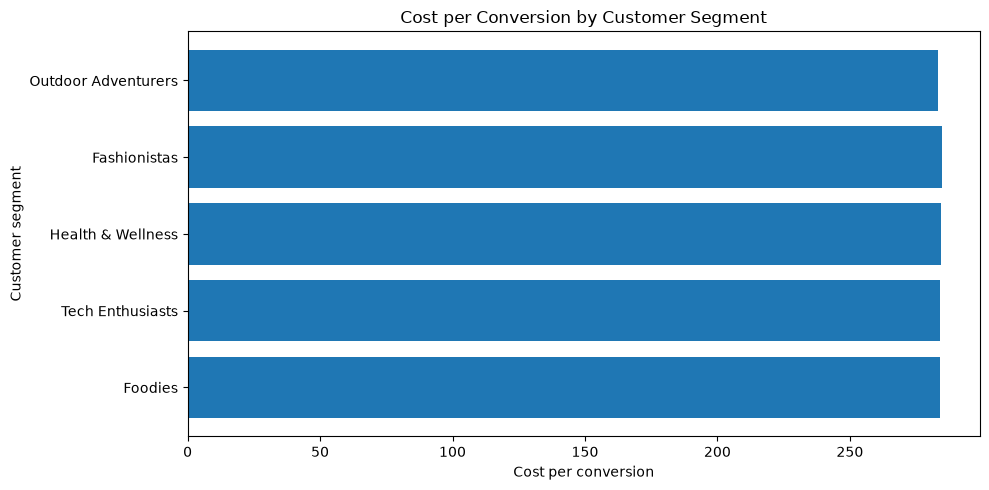

In [23]:
segment_summary = performance_summary("customer_segment")
display(segment_summary)

plt.figure()
plt.barh(segment_summary["customer_segment"], segment_summary["cost_per_conversion"])
plt.title("Cost per Conversion by Customer Segment")
plt.xlabel("Cost per conversion")
plt.ylabel("Customer segment")
plt.tight_layout()
plt.savefig("../visuals/cost_per_conversion_by_segment.png", dpi=150)
plt.show()

## 12. Monthly Trend Analysis

,year_month,campaigns,total_cost,avg_roi,avg_conversion_rate,clicks,impressions,estimated_conversions,ctr,cost_per_conversion
0,2021-01,16988,"212,138,826.00",5.01,0.08,9349618,92956072,"749,491.18",0.10,283.04
1,2021-02,15344,"191,464,820.00",5.01,0.08,8433037,84493850,"675,456.07",0.10,283.46
2,2021-03,16988,"211,892,603.00",4.98,0.08,9367374,93804488,"748,426.78",0.10,283.12
3,2021-04,16440,"205,452,322.00",4.99,0.08,8992709,90677348,"722,223.93",0.10,284.47
4,2021-05,16988,"211,663,415.00",5.02,0.08,9335696,93384968,"746,905.89",0.10,283.39
5,2021-06,16440,"205,516,710.00",4.99,0.08,9046697,91119478,"725,166.85",0.10,283.41
6,2021-07,16988,"212,239,503.00",4.98,0.08,9347146,93060793,"748,751.25",0.10,283.46
7,2021-08,16988,"213,545,454.00",5.00,0.08,9308212,93801223,"740,757.97",0.10,288.28
8,2021-09,16440,"206,273,900.00",5.03,0.08,9069330,90658302,"728,942.53",0.10,282.98
9,2021-10,16988,"212,709,908.00",5.02,0.08,9384834,93264009,"750,725.00",0.10,283.34


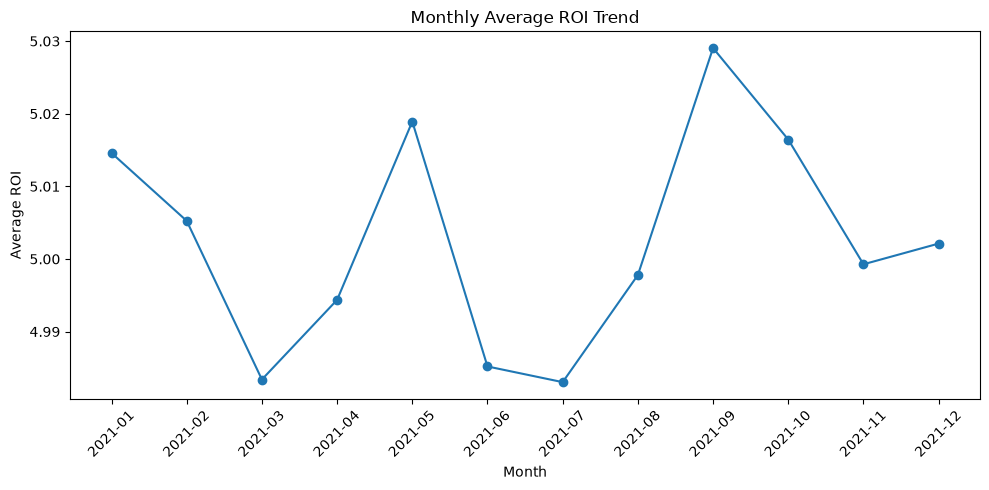

In [24]:
monthly_summary = (
    cleaned_df.groupby("year_month")
    .agg(
        campaigns=("campaign_id", "count"),
        total_cost=("acquisition_cost", "sum"),
        avg_roi=("roi", "mean"),
        avg_conversion_rate=("conversion_rate", "mean"),
        clicks=("clicks", "sum"),
        impressions=("impressions", "sum"),
        estimated_conversions=("estimated_conversions", "sum")
    )
    .reset_index()
)

monthly_summary["ctr"] = monthly_summary["clicks"] / monthly_summary["impressions"]
monthly_summary["cost_per_conversion"] = monthly_summary["total_cost"] / monthly_summary["estimated_conversions"]

display(monthly_summary)

plt.figure()
plt.plot(monthly_summary["year_month"], monthly_summary["avg_roi"], marker="o")
plt.title("Monthly Average ROI Trend")
plt.xlabel("Month")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/monthly_avg_roi_trend.png", dpi=150)
plt.show()

## 13. Top 10 Campaigns by ROI

In [25]:
top_10_roi = cleaned_df.sort_values("roi", ascending=False).head(10)[[
    "campaign_id",
    "company",
    "campaign_type",
    "channel_used",
    "target_audience",
    "customer_segment",
    "acquisition_cost",
    "roi",
    "conversion_rate",
    "clicks",
    "impressions",
    "engagement_score",
    "date"
]]

top_10_roi

,campaign_id,company,campaign_type,channel_used,target_audience,customer_segment,acquisition_cost,roi,conversion_rate,clicks,impressions,engagement_score,date
65640,65641,Alpha Innovations,Search,Website,Women 25-34,Foodies,"18,624.00",8.00,0.09,135,8364,9,2021-11-02
143790,143791,Alpha Innovations,Influencer,Website,Men 18-24,Foodies,"17,371.00",8.00,0.06,290,3637,3,2021-12-12
143503,143504,Innovate Industries,Influencer,YouTube,Women 35-44,Fashionistas,"5,889.00",8.00,0.04,660,4459,5,2021-02-28
121639,121640,TechCorp,Influencer,Google Ads,Men 18-24,Fashionistas,"7,081.00",8.00,0.14,350,1682,7,2021-04-05
120917,120918,TechCorp,Social Media,Website,Men 18-24,Foodies,"6,677.00",8.00,0.11,465,2766,9,2021-04-13
73364,73365,Innovate Industries,Display,Website,Men 25-34,Foodies,"5,277.00",8.00,0.15,511,6270,5,2021-12-31
48870,48871,TechCorp,Display,Website,Men 25-34,Foodies,"6,670.00",8.00,0.12,754,9802,10,2021-11-22
42868,42869,DataTech Solutions,Display,Website,Women 35-44,Tech Enthusiasts,"5,659.00",8.00,0.01,724,3588,8,2021-06-13
42999,43000,NexGen Systems,Email,Google Ads,All Ages,Outdoor Adventurers,"12,833.00",8.00,0.09,870,7386,4,2021-10-22
83445,83446,Alpha Innovations,Search,Email,Women 35-44,Foodies,"18,956.00",8.00,0.04,743,8741,2,2021-08-14


## 14. Correlation Analysis

In [27]:
numeric_cols = [
    "conversion_rate",
    "acquisition_cost",
    "roi",
    "clicks",
    "impressions",
    "ctr",
    "estimated_conversions",
    "cost_per_click",
    "cost_per_conversion",
    "engagement_score",
    "duration_days"
]

corr = cleaned_df[numeric_cols].corr()
corr

,conversion_rate,acquisition_cost,roi,clicks,impressions,ctr,estimated_conversions,cost_per_click,cost_per_conversion,engagement_score,duration_days
conversion_rate,1.00,0.00,-0.00,0.00,-0.00,-0.00,0.69,0.00,-0.48,-0.00,-0.00
acquisition_cost,0.00,1.00,0.00,0.00,0.00,-0.00,-0.00,0.41,0.23,-0.00,0.00
roi,-0.00,0.00,1.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
clicks,0.00,0.00,-0.00,1.00,0.00,0.51,0.64,-0.73,-0.40,-0.00,-0.00
impressions,-0.00,0.00,0.00,0.00,1.00,-0.66,-0.00,-0.00,0.00,0.00,-0.01
ctr,-0.00,-0.00,-0.00,0.51,-0.66,1.00,0.33,-0.37,-0.20,-0.01,0.00
estimated_conversions,0.69,-0.00,-0.00,0.64,-0.00,0.33,1.00,-0.47,-0.49,-0.00,-0.00
cost_per_click,0.00,0.41,0.00,-0.73,-0.00,-0.37,-0.47,1.00,0.55,0.00,0.00
cost_per_conversion,-0.48,0.23,0.00,-0.40,0.00,-0.20,-0.49,0.55,1.00,0.00,0.01
engagement_score,-0.00,-0.00,0.00,-0.00,0.00,-0.01,-0.00,0.00,0.00,1.00,-0.00


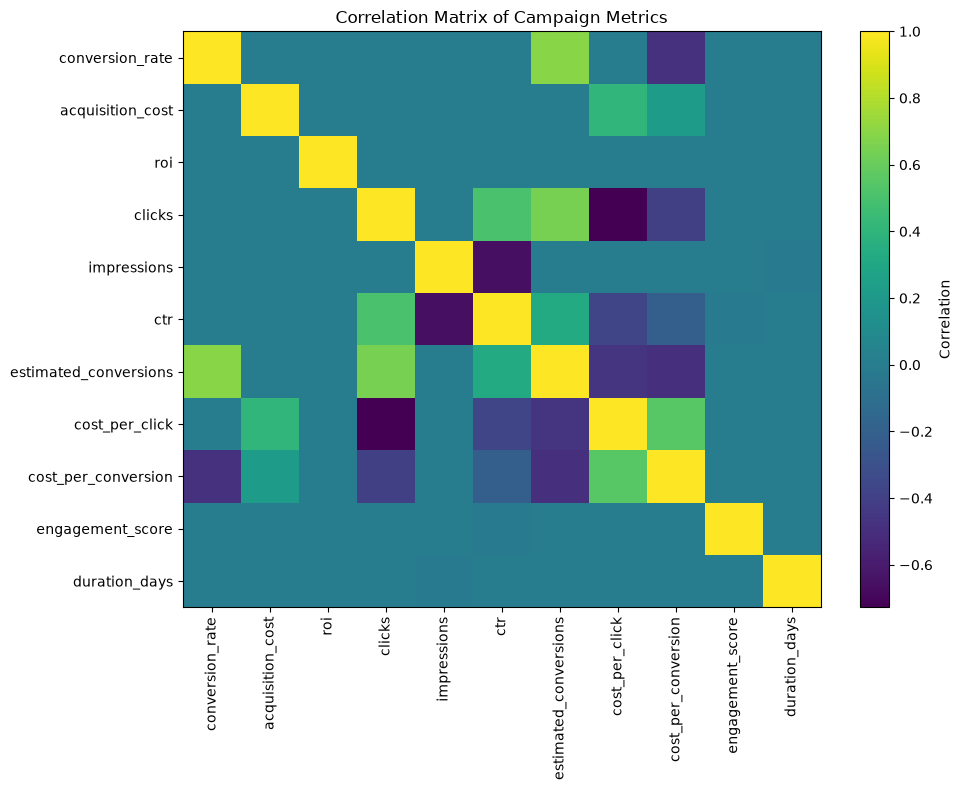

In [28]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix of Campaign Metrics")
plt.tight_layout()
plt.savefig("../visuals/correlation_matrix.png", dpi=150)
plt.show()

## 15. Business Insights

Update this section after reviewing the outputs.

Initial insight directions:
1. Compare ROI by channel.
2. Compare cost per conversion by customer segment.
3. Compare campaign types by conversion rate.
4. Identify monthly ROI patterns.
5. Identify high-performing campaigns.
6. Recommend budget allocation based on ROI and cost efficiency.

## 16. Business Recommendations

Draft recommendations:
1. Increase investment in channels with stronger ROI and lower cost per conversion.
2. Review underperforming campaign types with lower conversion rates.
3. Use customer segment performance to improve audience targeting.
4. Monitor monthly performance trends to adjust campaign timing.
5. Evaluate top campaigns and replicate their channel, audience, and creative strategy.